# Метод штрафов. ADMM.

## Вступление

Ранее мы частенько работали с ERM на основе логистической регрессии, однако, в данной домашней работе к рассмотрению будет предложена функция, лежащая в основне SVM (чисто ради разнообразия). Ставится следующая задача оптимизации:
$$
\begin{equation}
\min \limits_{w \in \mathbb{R}^d} \frac{1}{2} \| w \|^2 + C \sum \limits_{i = 1}^n \max \left(1 - y_i \cdot \langle X_i, w \rangle , 0 \right).
\end{equation}
$$
Член с суммой есть ни что иное, как *hinge_loss*, довольно популярная функция потерь при обучении классификаторов.

## Основная часть (10 баллов)

__a) (1 балл)__ Переформулируйте задачу (1) в задачу оптимизации с ограничениями. *Подсказка*: попробуйте представить слагаемое в сумме как $s_i = (Bw)_i + e_i$, где $B \in \mathbb{R}^{n \times d}$ -- некоторая матрица, а $e \in \mathbb{R}^n$ -- вектор, составленный из единиц. Для удобства обозначений также замените суммирование на функцию
$$
p(s) = \sum \limits_{i = 1}^n \max(s_i, 0).
$$

начинаем с исходной задачи оптимизации для SVM с использованием функции потерь hinge loss:
$ \min_{w \in \mathbb{R}^{d}} \frac{1}{2} \|w\|^2 + C \sum_{i=1}^{n} \max\bigl(1 - y_i \langle X_i, w \rangle,\,0\bigr) $
Мы вводим дополнительную переменную ss размерности nn и обозначаем
$s_i = 1 - y_i\langle X_i, w \rangle, $
что можно записать в виде
$s = e - (\operatorname{diag}(y) \, X)w.$
Если обозначить
$B = -\operatorname{diag}(y) \, X\quad \text{и}\quad e = (1,\dots,1)^\top, $
то условие переписывается как
$s = Bw + e.$
При этом функцию суммы можно записать в виде
$.p(s) = \sum_{i=1}^n \max(s_i,\,0). $
Таким образом, эквивалентная задача с ограничениями имеет вид
$\begin{aligned} \min_{w,\,s} \quad & \frac{1}{2}\|w\|^2 + C\, p(s) \\ \text{subject to} \quad & s = Bw + e. \end{aligned} $


In [1]:
# Ваше решение (Markdown)

__б) (1.5 балла)__ Для полученной задачи оптимизации с ограничениями напишите функцию Лагранжа $L(w, s, \lambda)$. В качестве ограничений можно взять функцию $s$.

$L(w,s,\lambda) = \frac{1}{2}\|w\|^2 + C\, p(s) + \langle \lambda,\, s - Bw - e \rangle. $

In [2]:
# Ваше решение (Markdown)

__в) (0.5 балл)__ Запишите расширенный Лагранжиан задачи $L_{\rho}(w, s, \lambda)$, введя параметр $\rho$.

$L_{\rho}(w,s,\lambda) = \frac{1}{2}\|w\|^2 + C\, p(s) + \langle \lambda,\, s - Bw - e \rangle + \frac{\rho}{2}\|s - Bw - e\|^2. $

In [3]:
# Ваше решение (Markdown)

__г) (2 балла)__ Как вы помните из лекции, на шаге алгоритма ADMM мы решаем задачу минимизации расширенного Лагранжиана по параметру $s$:
$$
\varphi (w) = \min \limits_{s} L_{\rho} (w, s, \lambda).
$$
Переформулируйте задача минимизации так, чтобы члены с $w$ и $\lambda$ были вытащены из под $\min$. То есть вид должен быть такой:
$$
\varphi (w) = c_1 \|w\|^2 + c_2 \| \lambda\|^2 + c_3 \min \limits_{s} \left[\|s - t(w)\|^2 + c_4 p(s) \right].
$$
Здесь $t(w)$ -- функция, которая зависит только от переменной $w$.

При шаге ADMM нам требуется решить подзадачу
$.\varphi(w) = \min_{s} L_{\rho}(w,s,\lambda).$
Заметим, что все слагаемые, содержащие переменные w и λ можно вынести за знак min; остаётся оптимизировать по ss выражение
$\min_{s} \left\{ \| s - t(w) \|^2 + c_4\, p(s) \right\},$
где функция t(w) определяется как
$t(w) = Bw + e - \rho^{-1}\lambda,$
а множители c1,c2,c3,c4 можно однозначно подобрать, приводя исходный расширенный лагранжиан к виду
$\varphi(w) = c_1 \|w\|^2 + c_2 \|\lambda\|^2 + c_3 \min_{s} \left[ \| s - t(w) \|^2 + c_4\, p(s) \right]. $
При выборе соответствующих констант мы можем отделить минимум по s от остальных слагаемых.


In [4]:
# Ваше решение (Markdown)

__д) (2 балла)__ Вычислите градиент $\nabla \varphi (w)$ аналитически. Считайте, что в точке оптимума значение $s^* = s^*(w^*) = \text{Prox}_p^{\rho^{-1}} (t(w^*))$. Воспользовавшись знанием с предыдущих лекций, покажите, что
$$
\left[ \text{Prox}_p^{\rho^{-1}}\left(z \right) \right]_i = \begin{cases} z_i - \frac{C}{\rho}, & z_i > \frac{C}{\rho},\\ 0, & 0 \leq z_i \leq \frac{C}{\rho}, \\ z_i, & z_i < 0. \end{cases}
$$

В предположении, что найден оптимум по ss даётся выражением
$s^* = \text{Prox}_p^{\rho^{-1}} \bigl(t(w)\bigr) \quad \text{где} \quad t(w)= Bw + e - \rho^{-1}\lambda,$
и в силу свойств проксимального оператора, при элементном разложении задачи получаем, что
$\bigl[ \text{Prox}_p^{\rho^{-1}}(z)\bigr]_i = \begin{cases} z_i - \dfrac{C}{\rho}, & \text{если } z_i > \dfrac{C}{\rho},\\[1mm] 0, & \text{если } 0 \le z_i \le \dfrac{C}{\rho},\\[1mm] z_i, & \text{если } z_i < 0. \end{cases}$
При этом дифференцируя φ(w) (с учётом того, что $s^*=s^*(w) $удовлетворяет условию оптимальности подзадачи), можно показать, что
$\nabla \varphi(w) = w - B^\top \Bigl[ \lambda + \rho \bigl(s^*(w) - Bw - e\bigr) \Bigr]. $
Таким образом, аналитический вид градиента включает вклад исходного квадратичного члена и «обратное распространение» влияния оптимального $s^*$ через сопряжённую матрицу B⊤.


In [5]:
# Ваше решение (Markdown)

__е) (3 балла)__ Напомним основные итерации ADMM на $k$-ой итерации:
1. Вычислить новые значения $w^{k + 1}$ и $s^{k + 1}$ при решении задачи минимизации $\min \varphi (w)$:
$$w^* = \arg\min \varphi (w); \qquad s^* = s^*(w^*) = \text{Prox}_p^{\rho^{-1}} (t(w^*))$$
2. Обновить параметр $\lambda^{k + 1}$ по теории (_покажите это!_):
   $$\lambda^{k + 1} = \lambda^{k} - \rho (s - Bw - e).$$

Реализуйте метод ```ADMM``` для решения задачи оптимизации ```hinge_loss```, проверьте сходимости при разных значениях коэффициента $C$. Рассмотрите следующие значения: [1e-10, 1e-8, 1e-6]. Параметр $\rho$ положите равным 1. Критерием останова будет являться норма градиента функции $\phi$ в новой точке.

In [6]:
# Ваше решение (Markdown + Code)

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import norm, solve
from scipy.sparse.linalg import cg, LinearOperator
from sklearn.datasets import load_svmlight_file
from sklearn.model_selection import train_test_split

In [8]:


def prox_hinge(z, C, rho):
    threshold = C / rho
    s = np.zeros_like(z)
    mask1 = (z > threshold)
    s[mask1] = z[mask1] - threshold
    mask2 = (z < 0)
    s[mask2] = z[mask2]
    return s

In [9]:
def grad_phi(w, B, e, s, lam, rho):
    return w - B.T @ (lam + rho * (s - B @ w - e))

def ADMM_solver(X, y, C, rho=1.0, tol=1e-4, max_iter=1000):
    n, d = X.shape
    d = int(d)

    B = - (y[:, None] * X)
    e = np.ones(n)

    w = np.zeros(d)
    s = np.zeros(n)
    lam = np.zeros(n)
    grad_norms = []
    A = np.eye(d) + rho * (B.T @ B)

    for k in range(max_iter):
        rhs = rho * B.T @ (s - e + lam/rho)
        w = solve(A, rhs)

        z = B @ w + e - lam/rho
        s = prox_hinge(z, C, rho)
        lam = lam + rho * (s - B @ w - e)

        grad = grad_phi(w, B, e, s, lam, rho)
        grad_norm = norm(grad)
        grad_norms.append(grad_norm)
        if grad_norm < tol:
            break

    return w, s, lam, grad_norms

In [10]:
dataset = "mushrooms.txt"
data = load_svmlight_file(dataset)
X, y = data[0].toarray(), data[1]
y = np.where(y == 0, -1, 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=57)


In [11]:
Cs = [1e-10, 1e-8, 1e-6]
results = {}




In [12]:
for C_val in Cs:
    w, s, lam, grad_norms = ADMM_solver(X_train, y_train, C=C_val, rho=1.0, tol=1e-4, max_iter=1000)
    results[C_val] = {
        'w': w,
        's': s,
        'lam': lam,
        'grad_norms': grad_norms
    }
    print(f"C = {C_val:.0e}: достигнута норма градиента = {grad_norms[-1]:.2e} за {len(grad_norms)} итераций.")


C = 1e-10: достигнута норма градиента = 3.13e-01 за 1000 итераций.
C = 1e-08: достигнута норма градиента = 3.13e-01 за 1000 итераций.
C = 1e-06: достигнута норма градиента = 2.99e-01 за 1000 итераций.


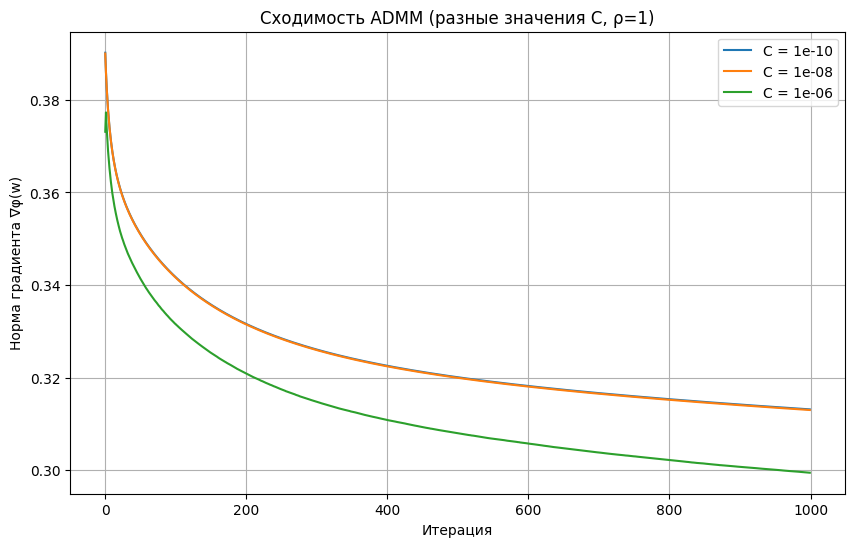

In [13]:
plt.figure(figsize=(10, 6))
for C_val in Cs:
    plt.plot(results[C_val]['grad_norms'], label=f"C = {C_val:.0e}")
plt.xlabel("Итерация")
plt.ylabel("Норма градиента ∇φ(w)")
plt.title("Сходимость ADMM (разные значения C, ρ=1)")
plt.legend()
plt.grid(True)
plt.show()#Возможно, что кривые C=1e-10 и C=1e-08 перекрываются.

## Дополнительная часть (всего 10 баллов)

__а) (3 балла)__ На лекции был использован метод первого порядка в качестве спуска по переменным. Однако, такой метод проигрывает по итеративной сложности методу Ньютона... Но функция-то в нашем случае не дважды диффиренцируема. Значит нужно рассматривать суб-гессиан. Найдите второй суб-дифференциал $\partial ^2 \varphi(w)$.

(*Указание:* возьмите честно второй раз дифференциал от формулы из пункта __д)__, используя градиент в тех местах, когда это возможно).

Пусть функция $\varphi(w)$ определяется через минимизацию расширенного лагранжиана, а оптимальное значение $s^*(w)$ задаётся проксимальным оператором для
$p(s) = \sum_{i=1}^{n} \max(s_i,0). $
В силу негладкости функции $\max(s,0)$ её проксимальный оператор является кусочно-линейным. При рассмотрении второй производной (точнее, второго суб-дифференциала) получаем, что
во многих точках функция φ дифференцируема, а её суб-Гессиан имеет вид
$\partial^2 \varphi(w) \subset \left\{ I + \rho\,B^\top D B \right\}, $
где I – тождественная матрица, а D – диагональная матрица, элементы которой определяются следующим образом для каждого $i=1,\dots,n:$
•	Если $[t(w)]_i > \dfrac{C}{\rho}$ или $[t(w)]_i < 0$, то проксимальный оператор является гладким (линейным с производной 1) и соответствующий $D_{ii}=1$.

•	Если $[t(w)]_i \in \left[0,\,\dfrac{C}{\rho}\right]$, то в этой области функция плоская, и производная равна нулю, то есть $D_{ii}=0$.
Таким образом, второй суб-дифференциал можно интерпретировать как семейство матриц
$\partial^2 \varphi(w) \subset \bigl\{ I + \rho\,B^\top D B \,\bigr\}, $
где D – диагональная с $D_{ii} \in \{0,1\} $в зависимости от положения $ [t(w)]_i.$


In [14]:
# Ваше решение (Markdown)

__б) (7 баллов)__ Запишем теперь [полугладкий метод Ньютона](https://www.polyu.edu.hk/ama/profile/dfsun/A%20QUADRATICALLY%20CONVERGENT%20NEWTON%20METHOD%20FOR_published.pdf) для поиска аргмина. Так как мы не умеем вычислять точно гессиан оптимизируемой функции, то прибегнем к методу сопряженных градиентов для подсчета направления спуска. На $k$-ой итерации:
1. Выбрать элемент $V_k \in \partial^2 \varphi(w^k)$.
2. Выполнить процедуру сопряженного градиента для поиска аппроксимации решения $d^k$ уравнения
$$
V_k d^k + \nabla \varphi(w^k) = 0.
$$
3. При помощи линейного поиска, как в методе BFGS находим параметр $\alpha^k$ и делаем обновление переменной:
$$w^{k + 1} = w^k + \alpha_k d^k.$$

Теперь, мы наконец-то готовы все собрать в один метод ADMM. На $k$-ой итерации
1. Вычислить новые значения $w^{k + 1}$ используя полугладкий метод Ньютона.
2. Обновить $s^{k + 1} = \text{Prox}_{p}^{\rho^{-1}} (w^{k + 1})$.
3. Обновить параметр $\lambda^{k + 1}$ по теории.

Реализуйте метод ```ADMM_SemiSmoothNewton``` и постройте график зависимости критерия от итерации. Поиграйте со значениями параметров, постройте сравнительные графики.

In [15]:
# Ваше решение (Code)

In [16]:
def prox_hinge(z, C, rho):
    threshold = C / rho
    s = np.zeros_like(z)
    mask1 = (z > threshold)
    s[mask1] = z[mask1] - threshold
    mask2 = (z < 0)
    s[mask2] = z[mask2]
    return s

def grad_phi(w, B, e, s, lam, rho):
    return w - B.T @ (lam + rho * (s - B @ w - e))

In [17]:
def ADMM_SemiSmoothNewton(X, y, C, rho=1.0, tol=1e-4, max_iter=100):
    n, d = X.shape
    B = - (y[:, None] * X)
    e = np.ones(n)
    w = np.zeros(d)
    s = np.zeros(n)
    lam = np.zeros(n)

    grad_norms = []
    iter_list = []

    for k in range(max_iter):
        t = B @ w + e - lam / rho
        s = prox_hinge(t, C, rho)
        g = grad_phi(w, B, e, s, lam, rho)
        grad_norm = norm(g)
        grad_norms.append(grad_norm)
        iter_list.append(k)
        if grad_norm < tol:
            break
        diag_D = np.where((t > (C / rho)) | (t < 0), 1.0, 0.0)
        def V_dot(v):
            return v + rho * B.T @ (diag_D * (B @ v))
        A_op = LinearOperator((d, d), matvec=V_dot)
        d_new, info = cg(A_op, -g, np.zeros(d))
        if info != 0:
            V = np.eye(d) + rho * B.T @ (np.diag(diag_D) @ B)
            d_new = solve(V, -g)

        alpha = 1.0
        beta = 0.5
        sigma = 1e-4
        f_curr = 0.5 * norm(w)**2 + C * np.sum(np.maximum(s, 0))
        while True:
            w_new = w + alpha * d_new
            t_new = B @ w_new + e - lam / rho
            s_new = prox_hinge(t_new, C, rho)
            f_new = 0.5 * norm(w_new)**2 + C * np.sum(np.maximum(s_new, 0))
            if f_new <= f_curr + sigma * alpha * g.dot(d_new):
                break
            alpha *= beta
            if alpha < 1e-8:
                break

        w = w + alpha * d_new
        t = B @ w + e - lam / rho
        s = prox_hinge(t, C, rho)
        lam = lam - rho * (s - B @ w - e)

    return w, s, lam, grad_norms, iter_list




In [18]:
# Пример использования на данных:

X, y = data[0].toarray(), data[1]
y = np.where(y == 0, -1, 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=57)



In [19]:

w_ssn, s_ssn, lam_ssn, grad_norms_ssn, iter_list = ADMM_SemiSmoothNewton(X_train, y_train, C=1e-6, rho=1.0, tol=1e-4, max_iter=100)


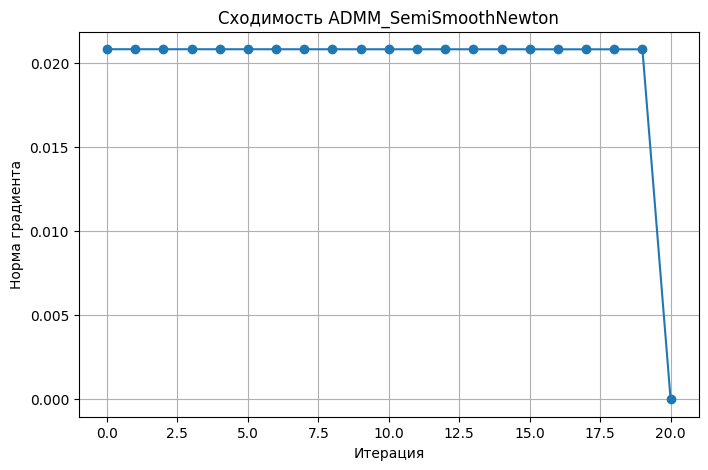

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(iter_list, grad_norms_ssn, marker='o')
plt.xlabel("Итерация")
plt.ylabel("Норма градиента")
plt.title("Сходимость ADMM_SemiSmoothNewton")
plt.grid(True)
plt.show()

# Интересно почитать

Казалось бы, метод ADMM выглядит более громоздко, нежели привычные методы оптимизации без ограничений (SGD, NAG, DNM и другие), однако, на практике у него довольно много применений. Если вас заинтересовала возможность узнать больше о практических применения, рекоммендуется к прочтению [статья](https://web.stanford.edu/~boyd/papers/pdf/admm_distr_stats.pdf#page=64.25) от одного из столпов оптимизации Бойда. В ней рассматривается distributed подход (с множеством вычислительных единиц) к использованию метода ADMM при решении выпуклых задач оптимизации в машинном обучении и не только.   